# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model, metrics, model_selection
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

## Exploratory Data Analysis 

In [22]:
df = pd.read_csv("data/Advertising.csv", index_col = 0, sep=",")
df

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    object 
 3   sales     200 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.8+ KB


In [12]:
df.describe()

,TV,radio,sales
count,200.000000,200.000000,200.000000
mean,147.042500,23.264000,14022.500000
std,85.854236,14.846809,5217.456566
min,0.700000,0.000000,1600.000000
25%,74.375000,9.975000,10375.000000
50%,149.750000,22.900000,12900.000000
75%,218.825000,36.525000,17400.000000
max,296.400000,49.600000,27000.000000


In [23]:
df["newpaper"] = df["newpaper"].str.replace("s", "").astype(float)
df["sales"] = df["sales"].round()
df

,TV,radio,newpaper,sales
0,230.1,37.8,69.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [24]:
df.describe()

,TV,radio,newpaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14022.500000
std,85.854236,14.846809,21.778621,5217.456566
min,0.700000,0.000000,0.300000,1600.000000
25%,74.375000,9.975000,12.750000,10375.000000
50%,149.750000,22.900000,25.750000,12900.000000
75%,218.825000,36.525000,45.100000,17400.000000
max,296.400000,49.600000,114.000000,27000.000000


#### REGULARIZACIÓN: LASSO

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    float64
 3   sales     200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


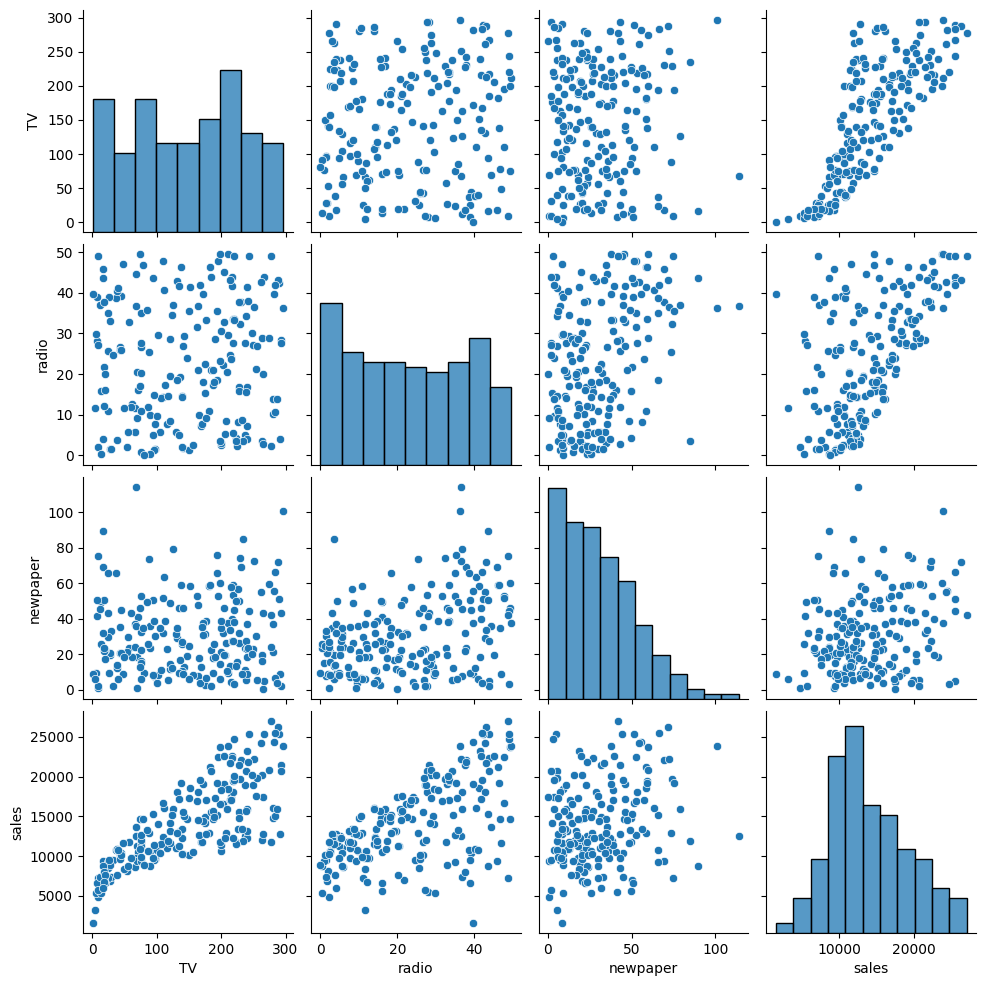

In [14]:
sns.pairplot(df)

<Axes: >

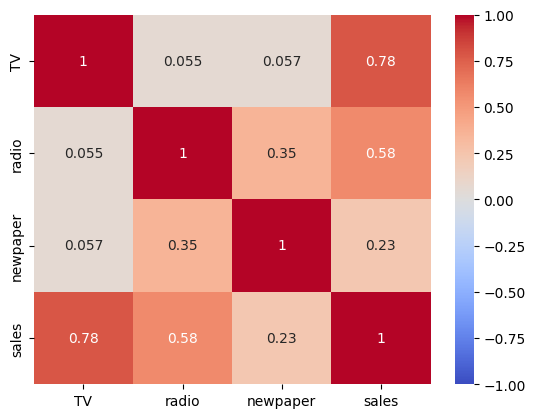

In [18]:
sns.heatmap(df.corr(), annot = True, cmap="coolwarm", vmin=-1)

In [25]:
X = df.drop(columns=["sales"])
y = df["sales"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.10, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(180, 3)
(180,)
(20, 3)
(20,)


#### REGULARIZACIÓN: LASSO

## Modelado

### MODELO DE LINEAR REGRESION

In [29]:
lm = LinearRegression()
lm.fit(X_train, y_train)

pred = lm.predict(X_test)

print("___________TEST___________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("MSE: ", metrics.mean_squared_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))



___________TEST___________
MAE:  1634.4001766856586
MSE:  6316064.95375604
RMSE:  2513.178257457286
MAPE:  0.39803011696555113
R2:  0.8213651186525016


### MODELO DE REGRESSION POLINÓMICA

In [33]:
grados = [2, 3, 4, 5, 6, 7]

for i in grados:
    print(f"\n===== Grado {i} =====")
    
    # Crear polinomios
    poly = PolynomialFeatures(degree=i)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Entrenar modelo
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predicciones en TEST
    pred = model.predict(X_test_poly)

    # Métricas
    print("MAE: ", metrics.mean_absolute_error(y_test, pred))
    print("MSE: ", metrics.mean_squared_error(y_test, pred))
    print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, pred)))
    print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
    print("R2: ", metrics.r2_score(y_test, pred))



===== Grado 2 =====
MAE:  719.0083387247776
MSE:  1752650.0263127002
RMSE:  1323.8768924309768
MAPE:  0.21213551014482795
R2:  0.9504304607716433

===== Grado 3 =====
MAE:  592.6579995367816
MSE:  1284551.6720787173
RMSE:  1133.3806386553094
MAPE:  0.17636134683855653
R2:  0.9636695098599242

===== Grado 4 =====
MAE:  555.7207085519101
MSE:  1108437.7381358142
RMSE:  1052.8236975561551
MAPE:  0.16541933206855824
R2:  0.9686504737866525

===== Grado 5 =====
MAE:  1432.3044588927598
MSE:  22097197.080326118
RMSE:  4700.765584490054
MAPE:  0.17750188258286712
R2:  0.37503331465757894

===== Grado 6 =====
MAE:  1381.9222868401448
MSE:  19235317.317463852
RMSE:  4385.8086275467895
MAPE:  0.162421925866497
R2:  0.455974779891512

===== Grado 7 =====
MAE:  11969.446106899248
MSE:  2614772441.068353
RMSE:  51134.84566387536
MAPE:  1.0066370729477603
R2:  -72.95262211215625


### MODELO POLINÓMICO DE 4 CON STANDARD SCALER

In [37]:
st = StandardScaler()
st.fit(X_train)

X_train_st = st.transform(X_train)
X_test_st = st.transform(X_test)

pol_model = PolynomialFeatures(degree=4)
pol_model.fit(X_train_st)

X_train_poly_4 = pol_model.transform(X_train_st)
X_test_poly_4 = pol_model.transform(X_test_st)

lm.fit(X_train_poly_4, y_train)
pred = lm.predict(X_test_poly_4)

print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("MSE: ", metrics.mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, pred)))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))

MAE:  555.7207034367045
MSE:  1108437.7009640115
RMSE:  1052.8236799027707
MAPE:  0.16541932816866037
R2:  0.9686504748379685


In [ ]:
intercept_scal = lm.intercept_
features_std = pd.DataFrame(lm.coef_, X_train.columns, columns=["coefficient"])
features_std.sort_values("coefficient", ascending=False)

AttributeError: 'LinearRegression' object has no attribute 'get_features_names_out'

## RIDGE

In [40]:
alphas = 100
alphas = np.logspace(-4, 3, 100)

coef = []
error = []
baseline = []

for i in alphas:

    ridge = Ridge(alpha=i)
    ridge.fit(X_train_st, y_train)

    pred = ridge.predict(X_test_st)

    print("MAE: ", metrics.mean_absolute_error(y_test, pred))
    print("MSE: ", metrics.mean_squared_error(y_test, pred))
    print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, pred)))
    print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
    print("R2: ", metrics.r2_score(y_test, pred))
    print("______________________________________")

    error.append(metrics.mean_squared_error(y_test, pred))
    baseline.append(6316064)


MAE:  1634.400708915063
MSE:  6316066.694876856
RMSE:  2513.1786038554555
MAPE:  0.39803019078585916
R2:  0.8213650694090386
______________________________________
MAE:  1634.4008030195178
MSE:  6316067.002729509
RMSE:  2513.1786651031216
MAPE:  0.3980302038381664
R2:  0.8213650607021583
______________________________________
MAE:  1634.4009137627395
MSE:  6316067.365014836
RMSE:  2513.1787371802343
MAPE:  0.39803021919827525
R2:  0.8213650504557791
______________________________________
MAE:  1634.4010440866518
MSE:  6316067.791357433
RMSE:  2513.1788220016165
MAPE:  0.3980302372742318
R2:  0.8213650383976924
______________________________________
MAE:  1634.4011974533416
MSE:  6316068.293083738
RMSE:  2513.1789218206764
MAPE:  0.3980302585462297
R2:  0.8213650242075566
______________________________________
MAE:  1634.4013779370289
MSE:  6316068.883522975
RMSE:  2513.179039289277
MAPE:  0.39803028357936526
R2:  0.8213650075083865
______________________________________
MAE:  1634.4015

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_6268\3655423274.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=20)


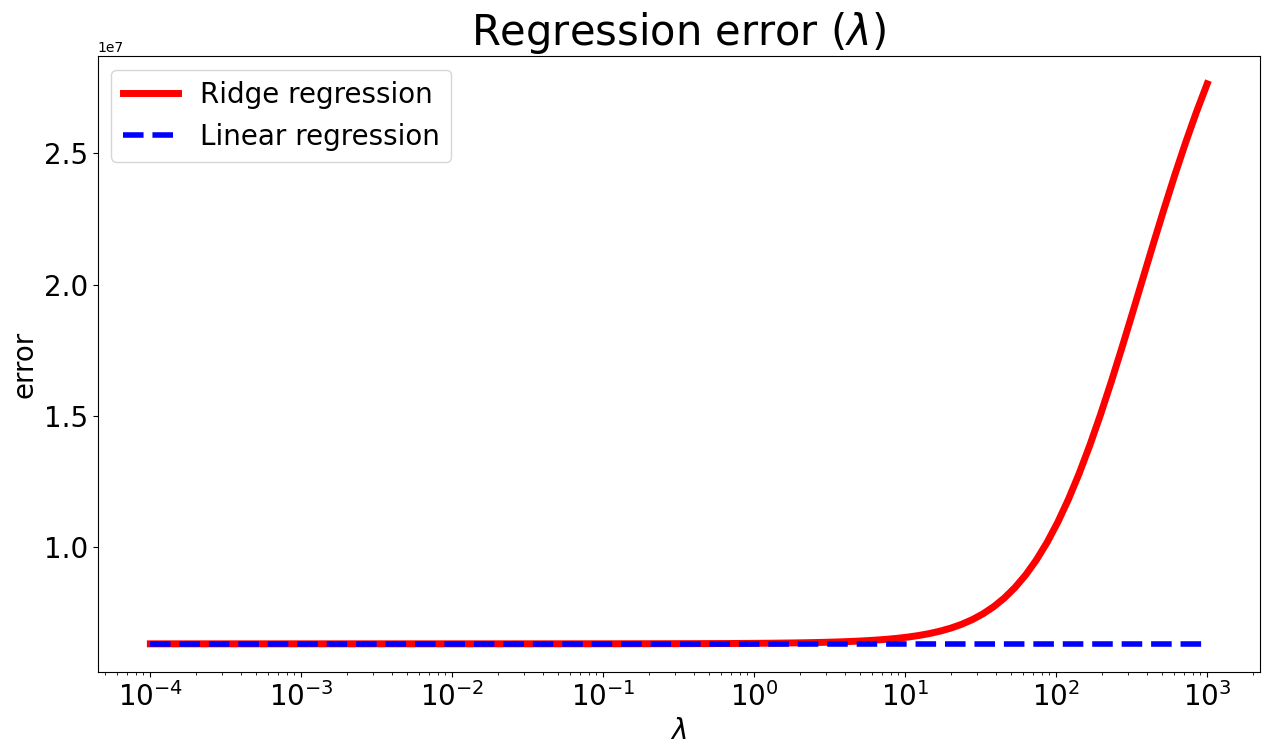

In [42]:
plt.figure(figsize=(15,8))
ax = plt.gca()
ax.plot(alphas, error, linewidth=5, color='red', label="Ridge regression")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel('$\lambda$', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('error', fontsize=20)
ax.legend(fontsize=20)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show();

## LASSO

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_st, y_train)

pred = lasso.predict(X_test_st)

print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("MSE: ", metrics.mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, pred)))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))

MAE:  1634.4294585151501
MSE:  6315930.17968471
RMSE:  2513.1514438419167
MAPE:  0.3980301209086999
R2:  0.8213689304166961


In [44]:
alphas = 100
alphas = np.logspace(-4, 3, 100)

coef = []
error = []
baseline = []

for i in alphas:

    ridge = Lasso(alpha=i)
    ridge.fit(X_train_st, y_train)

    pred = ridge.predict(X_test_st)

    print("MAE: ", metrics.mean_absolute_error(y_test, pred))
    print("MSE: ", metrics.mean_squared_error(y_test, pred))
    print("RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, pred)))
    print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
    print("R2: ", metrics.r2_score(y_test, pred))
    print("______________________________________")

    error.append(metrics.mean_squared_error(y_test, pred))
    baseline.append(6316064)

MAE:  1634.4002060641815
MSE:  6316064.819299831
RMSE:  2513.1782307070525
MAPE:  0.39803011698461077
R2:  0.8213651224552758
______________________________________
MAE:  1634.4002112906824
MSE:  6316064.796316871
RMSE:  2513.1782261345634
MAPE:  0.39803011701919777
R2:  0.8213651231052942
______________________________________
MAE:  1634.4002174412897
MSE:  6316064.769270243
RMSE:  2513.1782207536025
MAPE:  0.3980301170598996
R2:  0.8213651238702437
______________________________________
MAE:  1634.4002246793982
MSE:  6316064.73744146
RMSE:  2513.1782144212257
MAPE:  0.39803011710779834
R2:  0.8213651247704452
______________________________________
MAE:  1634.4002331972906
MSE:  6316064.699984972
RMSE:  2513.17820696921
MAPE:  0.398030117164166
R2:  0.8213651258298129
______________________________________
MAE:  1634.4002432212487
MSE:  6316064.655905744
RMSE:  2513.1781981995914
MAPE:  0.39803011723050036
R2:  0.8213651270764891
______________________________________
MAE:  1634.40025

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_6268\1839401975.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=30)


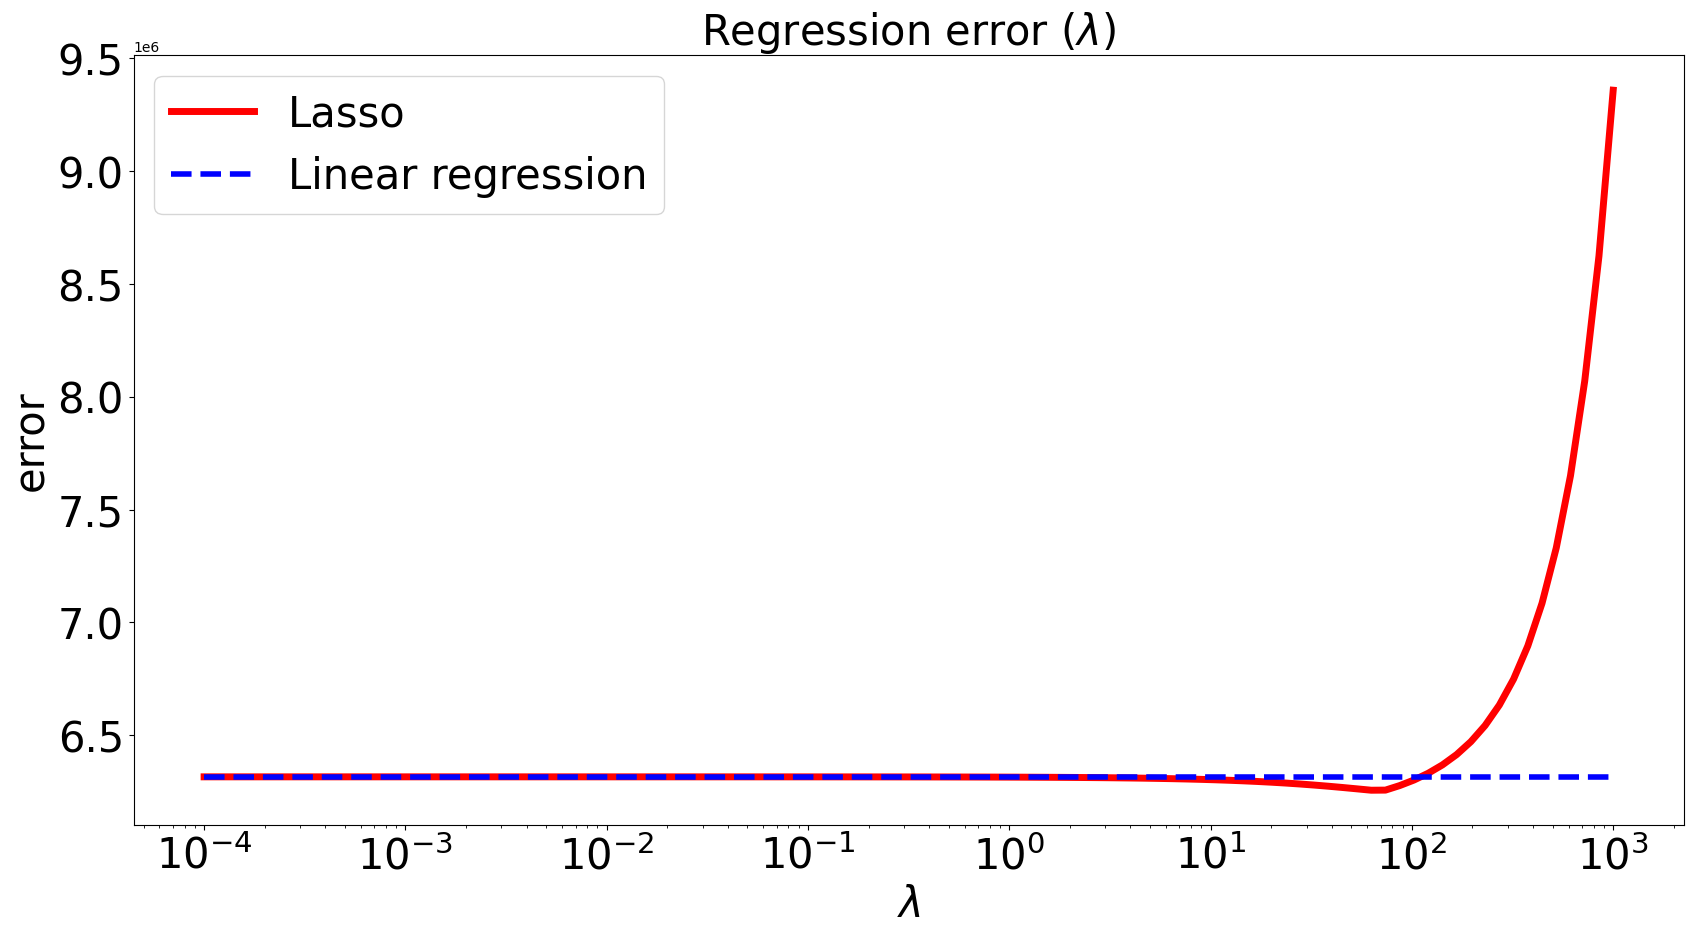

In [45]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, error, linewidth=5, color='red', label="Lasso")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel('$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()